In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import time
import gc
from scipy.stats import zscore
from scipy.signal import detrend
import copy
import sys
from scipy.integrate import simpson as simps
from nice.algorithms.connectivity import epochs_compute_wsmi
import mne
import warnings
warnings.filterwarnings("ignore")
from scipy.ndimage import gaussian_filter1d


def smooth_with_gaussian(data, sigma=3):
    return gaussian_filter1d(data, sigma=sigma, axis=1) 

def preprocess(data):
    stds = np.std(data[:, :], axis=0)
    non_constant_cols = stds.astype(float) > 1e-6    #finds the time points where std is not 0
    const_cols = stds.astype(float) <= 1e-6    #finds the time points where std is 0

    z = np.zeros_like(data[:, :])   #creates an array of zeros with the same shape as the data
    z[:, non_constant_cols] = zscore(data[:, non_constant_cols], axis=0)  #in the columns where std is not 0, zscores the data
    z[:, const_cols] = np.mean(data[:, const_cols], axis=0)

 
    if np.isnan(z).any():
        raise ValueError("Data contains NaN values after normalization.")

    return z


file_numbers = [1, 2, 4, 8, 14, 15, 20, 23]

wsmi_means = {f'dataset_{file_number}': {'left_attleft': [], 'right_attleft': [], 'left_attright': [], 'right_attright': []} for file_number in file_numbers}
wsmi_stdevs = {f'dataset_{file_number}': {'left_attleft': [], 'right_attleft': [], 'left_attright': [], 'right_attright': []} for file_number in file_numbers}

total_time = time.time()
for file_number in  file_numbers:
    file_total = time.time()
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    load_data_start_time = time.time()
    data = pickle.load(open(file_path, 'rb'))
    elapsed_time = time.time() - load_data_start_time
    print(f"Dataset {file_number} loaded in {elapsed_time:.2f} seconds")


    attention_labels = data['label_attend'][0]
    label_left = data['label_left'][0]
    label_right = data['label_right'][0]
    attend_01 = data['attend'][0]
    # omitted = data['omit'][0]
    # relevant = np.where(omitted ==0)[0]
    omitted = data['omit'][0]
    trial_correct = data['trial_correct'][0]
    relevant = np.where((omitted == 0) & (trial_correct == 1))[0]
 
    # left = data['SP'][0][0][relevant]
    # right = data['SP'][0][1][relevant]
    # attention_SP = data['SP'][0][2][relevant]

    # sigma = 2

    # left_sm = smooth_with_gaussian(left, sigma=sigma) 
    # right_sm = smooth_with_gaussian(right, sigma=sigma) 
    # att_sm = smooth_with_gaussian(attention_SP, sigma=sigma) 

    # num_trials, num_samples, num_neurons = left.shape
    # num_neurons_attention = 80
            
    # for j in range(0, num_trials):
    #     for i in range(0, num_neurons):
    #         count_left = np.count_nonzero(left[j, :, i] == 1)
    #         if count_left > 0:
    #             left_sm[j, :, i] /= count_left
    #         count_right = np.count_nonzero(right[j, :, i] == 1)
    #         if count_right > 0:
    #             right_sm[j, :, i] /= count_right


    #     for i in range(0, num_neurons_attention):
    #         count_attention = np.count_nonzero(attention_SP[j, :, i] == 1)
    #         if count_attention > 0:
    #             att_sm[j, :, i] /= count_attention


    # left = np.sum(left_sm, axis=2)
    # right = np.sum(right_sm, axis=2)
    # attention_SP = np.sum(att_sm, axis=2)

    # left = preprocess(left)
    # right = preprocess(right)
    # attention_SP = preprocess(attention_SP)

    # #preprocess here now that we have traces of all of the relavant trials
    # left_indices_agg = np.where((omitted ==0) & (attend_01 == 0))[0]  #indices of agg where left
    # _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   #indices for relevant processed data where attention left
    # right_indices_agg = np.where((omitted ==0) & (attend_01 == 1))[0]
    # _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    # #splitting left and right
    # left_attleft = left[left_indices, 100:350]
    # right_attleft = right[left_indices, 100:350]
    # attention_SP_attleft = attention_SP[left_indices, 100:350]

    # left_attright = left[right_indices, 100:350]
    # right_attright = right[right_indices, 100:350]
    # attention_SP_attright = attention_SP[right_indices, 100:350]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]

    num_trials, num_samples, num_neurons = left.shape
    num_neurons_attention = 80

    for j in range(0, num_trials):
        for i in range(0, num_neurons):
            count_left = np.count_nonzero(left[j, :, i] == 1)
            if count_left > 0:
                left[j, :, i] /= count_left
            count_right = np.count_nonzero(right[j, :, i] == 1)
            if count_right > 0:
                right[j, :, i] /= count_right

        for i in range(0, num_neurons_attention):
            count_attention = np.count_nonzero(att[j, :, i] == 1)
            if count_attention > 0:
                att[j, :, i] /= count_attention

    left = np.sum(left, axis=2)  # Return a single time series for the output
    right = np.sum(right, axis=2)  # Return a single time series for the output
    att = np.sum(att, axis=2)  # Return a single time series for the output

    left = preprocess(left)
    right = preprocess(right)
    att = preprocess(att)
   
    # Can now split into left and right attentional modality
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    # Splitting left and right
    left_attleft = smooth_with_gaussian(left[left_indices], sigma = 2)  # Axis 1 will smooth all of these across time
    right_attleft = smooth_with_gaussian(right[left_indices], sigma = 2)
    att_attleft = smooth_with_gaussian(att[left_indices], sigma = 2)

    left_attright = smooth_with_gaussian(left[right_indices], sigma = 2)
    right_attright = smooth_with_gaussian(right[right_indices], sigma = 2)
    att_attright = smooth_with_gaussian(att[right_indices], sigma = 2)


    #----------------------------------------------------------------
    sfreq = 500.0
    ch_names = ['left_input', 'right_input', 'attention_layer']
    ch_types = ['eeg', 'eeg', 'eeg']
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)


    data_left = np.stack([
        left_attleft, 
        right_attleft, 
        att_attleft 
    ], axis=1) 
    print(data_left.shape)

    epochs_left = mne.EpochsArray(
        data_left,
        info, 
        tmin=0, 
        baseline=None
    )

    data_right = np.stack([
        left_attright,
        right_attright,
        att_attright
    ], axis=1) 

    epochs_right = mne.EpochsArray(
        data_right,
        info,
        tmin=0,
        baseline=None
    )
  
    kernel = 3
    taus   = [4,8,16,32,64]
    wsmi_results = {'left':{}, 'right':{}}

    for tau in taus:
        tau_samples = int(tau / (1000/sfreq))
        wsmi_results['left'][tau], *_ = epochs_compute_wsmi(
            epochs_left, kernel=kernel, tau=tau_samples,
            backend='python', method_params={'bypass_csd':True}
        )
        wsmi_results['right'][tau], *_ = epochs_compute_wsmi(
            epochs_right, kernel=kernel, tau=tau_samples,
            backend='python', method_params={'bypass_csd':True}
        )


    for tau in taus:
        wsmi_means[f'dataset_{file_number}']['left_attleft'].append(np.mean(wsmi_results['left'][tau][0, 2, :]))
        wsmi_means[f'dataset_{file_number}']['right_attleft'].append(np.mean(wsmi_results['left'][tau][1, 2, :]))
        wsmi_means[f'dataset_{file_number}']['left_attright'].append(np.mean(wsmi_results['right'][tau][0, 2, :]))
        wsmi_means[f'dataset_{file_number}']['right_attright'].append(np.mean(wsmi_results['right'][tau][1, 2, :]))

        wsmi_stdevs[f'dataset_{file_number}']['left_attleft'].append(np.std(wsmi_results['left'][tau][0, 2, :], ddof = 1))
        wsmi_stdevs[f'dataset_{file_number}']['right_attleft'].append(np.std(wsmi_results['left'][tau][1, 2, :], ddof = 1))
        wsmi_stdevs[f'dataset_{file_number}']['left_attright'].append(np.std(wsmi_results['right'][tau][0, 2, :], ddof = 1))
        wsmi_stdevs[f'dataset_{file_number}']['right_attright'].append(np.std(wsmi_results['right'][tau][1, 2, :], ddof = 1))

  
    del left_attleft, right_attleft, att_attleft, left_attright, right_attright, att_attright
    gc.collect()
    del(data)
    gc.collect()
    print(f'Dataset {file_number} complete in', time.time() - file_total)

print('total time elapsed =', time.time() - total_time)


c:\Users\joshu\nice\.venv\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


Dataset 1 loaded in 11.94 seconds
(328, 3, 250)
Not setting metadata
Not setting metadata
328 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
350 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Cannot autodetect number of jobs
Bypassing CSD
Filtering  at 83.33 Hz
Performing symbolic transformation
Running wsmi with python...
Cannot autodetect number of jobs
Bypassing CSD
Filtering  at 83.33 Hz
Performing symbolic transformation
Running wsmi with python...
Cannot autodetect number of jobs
Bypassing CSD
Filtering  at 41.67 Hz
Performing symbolic transformation
Running wsmi with python...
Cannot autodetect number of jobs
Bypassing CSD
Filtering  at 41.67 Hz
Performing symbolic transformation
Running wsmi with python...
Cannot autodetect number of jobs
Bypassing CSD
Filtering  at 20.83 Hz
Performing symbolic transformation
Running wsmi with

[np.float64(0.020587944417530073), np.float64(0.0205308836856253), np.float64(0.021250019283257475), np.float64(0.020594999849547678), np.float64(0.022561215427203095), np.float64(0.0223227924796649), np.float64(0.020599859445361482), np.float64(0.020752000871282233), np.float64(0.019778286782735667), np.float64(0.020979777571482675), np.float64(0.019464885382610868), np.float64(0.02075042193983683), np.float64(0.02164987968317595), np.float64(0.02061495940473148), np.float64(0.02099556509405927), np.float64(0.0207040351125322)]
[np.float64(0.028113702113991026), np.float64(0.02805317817984511), np.float64(0.02851447107622393), np.float64(0.027595265604751236), np.float64(0.028681418400246253), np.float64(0.02838397933878351), np.float64(0.02881268617752647), np.float64(0.02766028483556509), np.float64(0.027305246143281954), np.float64(0.02862225689006645), np.float64(0.027090831804557843), np.float64(0.027735493715982495), np.float64(0.028773133648763372), np.float64(0.027740492124052

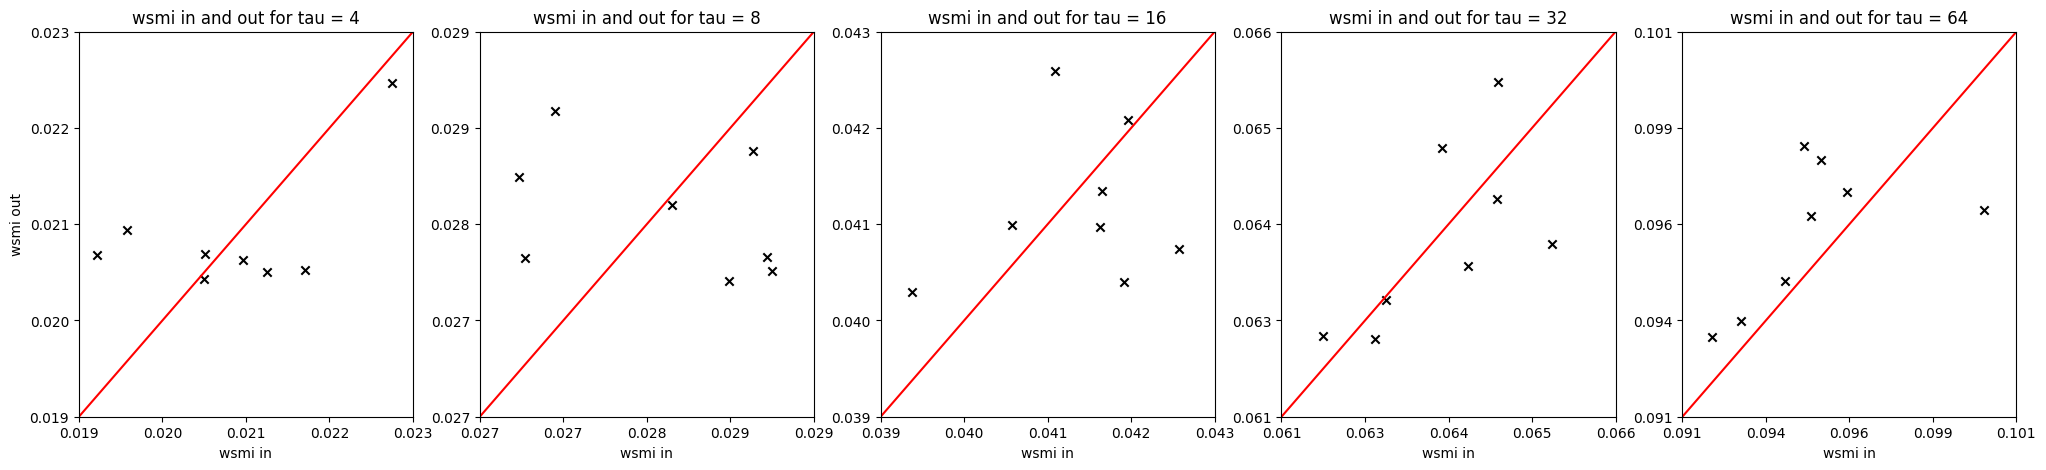

{'0': [np.float64(0.020587944417530073), np.float64(0.021250019283257475), np.float64(0.022561215427203095), np.float64(0.020599859445361482), np.float64(0.019778286782735667), np.float64(0.019464885382610868), np.float64(0.02164987968317595), np.float64(0.02099556509405927)], '1': [np.float64(0.028113702113991026), np.float64(0.02851447107622393), np.float64(0.028681418400246253), np.float64(0.02881268617752647), np.float64(0.027305246143281954), np.float64(0.027090831804557843), np.float64(0.028773133648763372), np.float64(0.027050113881763323)], '2': [np.float64(0.04187974002366998), np.float64(0.04185006248099146), np.float64(0.04215930131279555), np.float64(0.04284363534237368), np.float64(0.04129115886373664), np.float64(0.04074390493895269), np.float64(0.04220682388440728), np.float64(0.0394914102394063)], '3': [np.float64(0.0646217321658916), np.float64(0.06418571645431481), np.float64(0.0629378796532858), np.float64(0.06277911888861534), np.float64(0.06379587270196795), np.flo

In [14]:
taus = [0,1,2,3,4]
#want a single plot, where for each dataset, mean pearson in and mean pearson out are plotted with error bars
wsmi_in = {f'{tau}': [] for tau in taus}
wsmi_out = {f'{tau}': [] for tau in taus}
errors_in = {f'{tau}': [] for tau in taus}
errors_out = {f'{tau}': [] for tau in taus}


for file_number in file_numbers:
    values = []
    errors = []
    for tau in taus:
        for condition in ['left_attleft', 'right_attright']:
            values.append(wsmi_means[f'dataset_{file_number}'][condition][tau])
            errors.append(wsmi_stdevs[f'dataset_{file_number}'][condition][tau])
        wsmi_in[f'{tau}'].append(np.mean(values))
        errors_in[f'{tau}'].append(np.mean(errors))


    values = []
    errors = []
    for tau in taus:
        for condition in ['left_attright', 'right_attleft']:
            values.append(wsmi_means[f'dataset_{file_number}'][condition][tau])
            errors.append(wsmi_stdevs[f'dataset_{file_number}'][condition][tau])
        wsmi_out[f'{tau}'].append(np.mean(values))
        errors_out[f'{tau}'].append(np.mean(errors))

max_values = {f'{tau}': [] for tau in taus}
min_values = {f'{tau}': [] for tau in taus}

idx = np.arange(len(file_numbers))
for tau in taus:
    values = []
    for f in idx:
        values.append(wsmi_in[f'{tau}'][f])
        values.append(wsmi_out[f'{tau}'][f])
    print(values)
    max_values[f'{tau}'].append(max(values))
    min_values[f'{tau}'].append(min(values))

tau_values = [4, 8, 16, 32, 64]
N_ticks = 5  


fig, axs = plt.subplots(1,5, figsize=(25, 5))
for tau, i in zip(taus, range(5)):
    axs[i].scatter(wsmi_in[f'{tau}'], wsmi_out[f'{tau}'], marker = 'x', color='k')
    axs[i].plot([0, 1], [0, 1], transform=axs[i].transAxes, color='r')

    local_min = min_values[f'{tau}'][0] * 0.99
    local_max = max_values[f'{tau}'][0] * 1.01

    tick_values = np.linspace(local_min, local_max, N_ticks)
    axs[i].set_xlim(local_min, local_max)
    axs[i].set_ylim(local_min, local_max)
    axs[i].set_xticks(tick_values)
    axs[i].set_yticks(tick_values)
    axs[i].set_xticklabels([f"{tick:.3f}" for tick in tick_values])
    axs[i].set_yticklabels([f"{tick:.3f}" for tick in tick_values])

# Add error bars for each point
    # axs[i].errorbar(wsmi_in[f'{tau}'], wsmi_out[f'{tau}'],
    #                 xerr=errors_in[f'{tau}'], yerr=errors_out[f'{tau}'],
    #                     fmt='none', ecolor='gray', alpha=0.7, capsize=3)

    axs[i].set_xlabel('wsmi in')
    axs[0].set_ylabel('wsmi out')
    axs[i].set_title(f'wsmi in and out for tau = {tau_values[tau]}')
plt.show()


print(wsmi_in, wsmi_out)